# # Tesla Stock Price Prediction using SimpleRNN and LSTM

## Domain
Financial Services

## Objective
The goal of this project is to predict Tesla stock closing prices using deep learning models on historical time-series data. Two sequential models, SimpleRNN and LSTM, are developed and compared for 1-day, 5-day, and 10-day ahead forecasting.

## Why this approach
Stock prices are sequential in nature, so recurrent deep learning models are suitable for learning temporal dependencies. This project focuses on the Close price, as required in the problem statement.

# 2. Import libraries

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from scikeras.wrappers import KerasRegressor

print("Libraries imported successfully")

Libraries imported successfully


# 3. Load dataset

In [90]:
df = pd.read_csv("data/TSLA.csv")   # or use data/TSLA.csv if inside data folder
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,29-06-2010,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,30-06-2010,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,01-07-2010,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,02-07-2010,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,06-07-2010,20.000000,20.00,15.830000,16.110001,16.110001,6866900


# 4. Data inspection


In [91]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Shape of dataset: (2416, 7)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

First 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,29-06-2010,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,30-06-2010,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,01-07-2010,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,02-07-2010,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,06-07-2010,20.000000,20.00,15.830000,16.110001,16.110001,6866900



Last 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
2411,28-01-2020,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,29-01-2020,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,30-01-2020,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,31-01-2020,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,03-02-2020,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


# 5. Data cleaning and missing-value handling


## Missing Value Handling
For time-series data, missing values should be handled in a way that preserves temporal order. In this project, forward fill and backward fill were used because they are more suitable than random, mean, or median imputation for sequential stock data.

In [92]:
# Convert date and sort
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Handle missing values for time series
df = df.ffill().bfill()

print("\nMissing values after handling:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values after handling:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


# 6. EDA and visualization

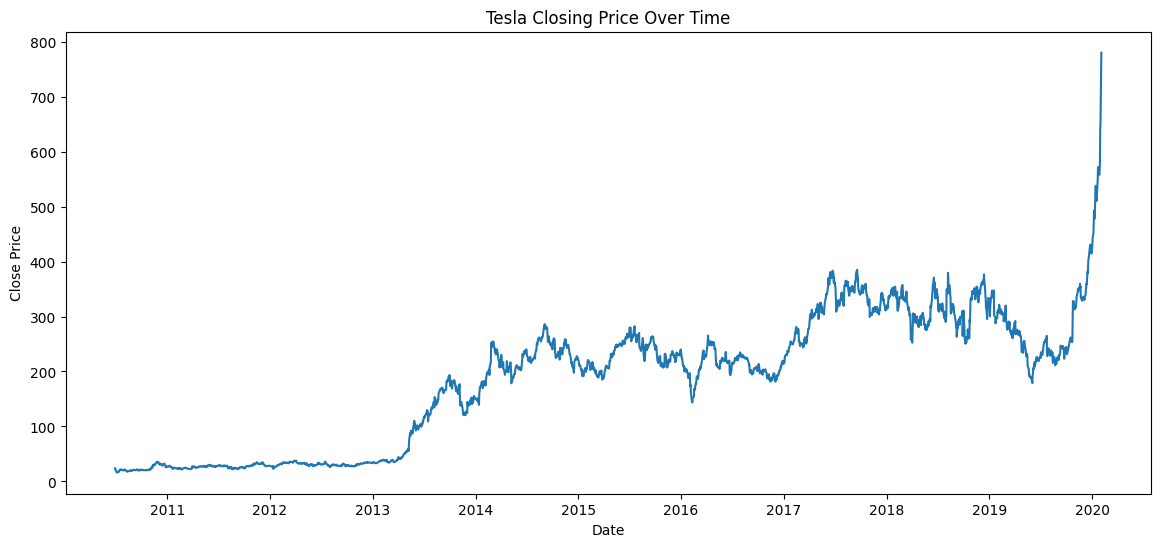

In [93]:
# Close price over time
plt.figure(figsize=(14,6))
plt.plot(df.index, df["Close"])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

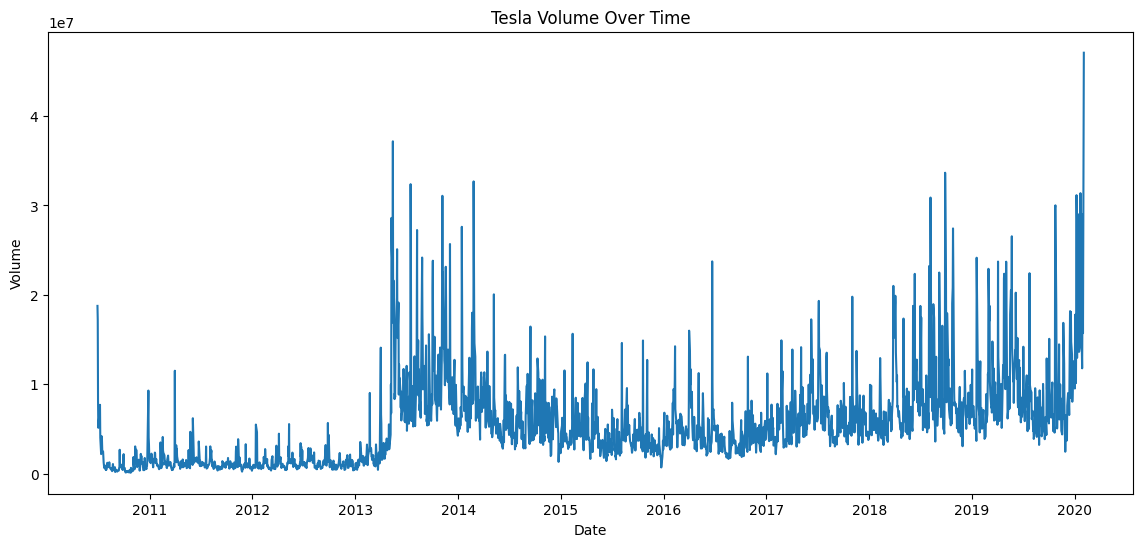

In [94]:
# Volume over time
plt.figure(figsize=(14,6))
plt.plot(df.index, df["Volume"])
plt.title("Tesla Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

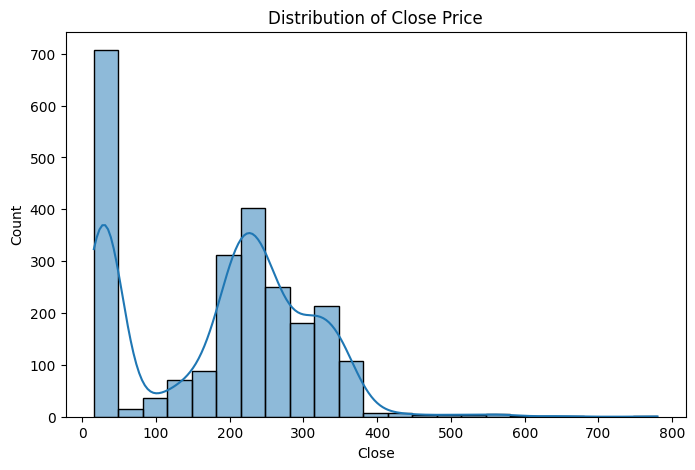

In [96]:
# Close price distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Close"], kde=True)
plt.title("Distribution of Close Price")
plt.show()

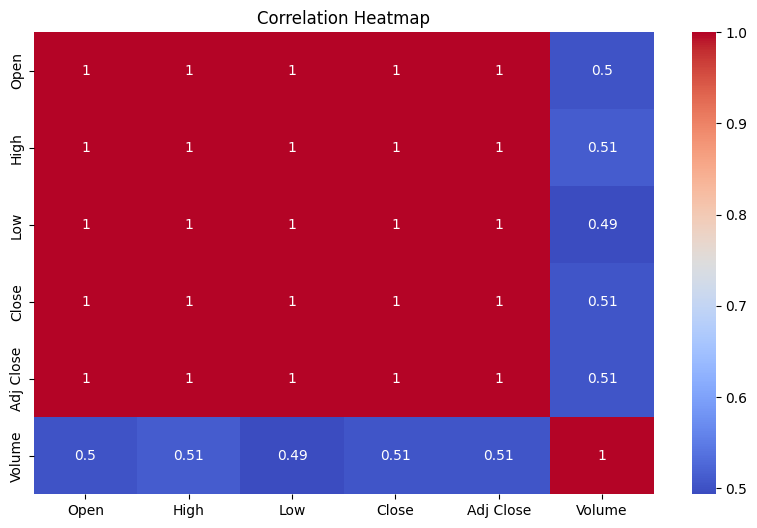

In [97]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

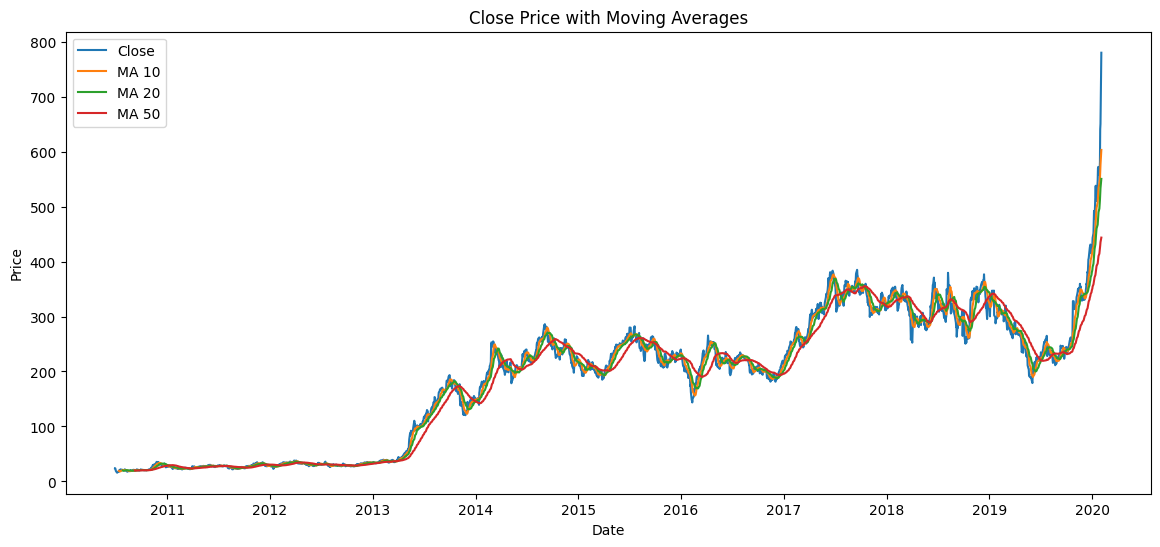

In [98]:
# Rolling averages
df["MA_10"] = df["Close"].rolling(10).mean()
df["MA_20"] = df["Close"].rolling(20).mean()
df["MA_50"] = df["Close"].rolling(50).mean()

plt.figure(figsize=(14,6))
plt.plot(df.index, df["Close"], label="Close")
plt.plot(df.index, df["MA_10"], label="MA 10")
plt.plot(df.index, df["MA_20"], label="MA 20")
plt.plot(df.index, df["MA_50"], label="MA 50")
plt.title("Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# 7. Feature selection


Although the dataset includes multiple stock-related features, this project uses the Close price as the target variable because the problem statement explicitly asks to analyze and predict the stock's closing price.

In [99]:
data = df[["Close"]].copy()
data.head()

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


# 8. Train-test split

In [100]:
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (1932, 1)
Test shape: (484, 1)


# 9. Scaling

In [101]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print(train_scaled.shape, test_scaled.shape)

(1932, 1) (484, 1)


# 10. Sequence generation

In [102]:
def create_sequences(dataset, lookback=60, horizon=1):
    X, y = [], []
    for i in range(lookback, len(dataset) - horizon + 1):
        X.append(dataset[i-lookback:i, 0])
        y.append(dataset[i + horizon - 1, 0])
    return np.array(X), np.array(y)

# 11. Build SimpleRNN and LSTM functions

In [103]:
def build_simplernn_model(input_shape, units=50, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        SimpleRNN(units=units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        SimpleRNN(units=units),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model


def build_lstm_model(input_shape, units=50, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units=units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        LSTM(units=units),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

# 12. 1-day prediction dataset

In [104]:
lookback = 60

X_train_1, y_train_1 = create_sequences(train_scaled, lookback=lookback, horizon=1)
combined_1 = np.concatenate((train_scaled[-lookback:], test_scaled), axis=0)
X_test_1, y_test_1 = create_sequences(combined_1, lookback=lookback, horizon=1)

X_train_1 = X_train_1.reshape((X_train_1.shape[0], X_train_1.shape[1], 1))
X_test_1 = X_test_1.reshape((X_test_1.shape[0], X_test_1.shape[1], 1))

print(X_train_1.shape, y_train_1.shape)
print(X_test_1.shape, y_test_1.shape)

(1872, 60, 1) (1872,)
(484, 60, 1) (484,)


# 13. Train SimpleRNN for 1-day

In [105]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

rnn_model_1 = build_simplernn_model((X_train_1.shape[1], 1))

history_rnn_1 = rnn_model_1.fit(
    X_train_1, y_train_1,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0895 - val_loss: 0.0041
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0179 - val_loss: 0.0054
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0133 - val_loss: 0.0062
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0106 - val_loss: 0.0031
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0086 - val_loss: 0.0116
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0080 - val_loss: 0.0034
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0079 - val_loss: 0.0053
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0063 - val_loss: 0.0034
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0054 - val_loss: 0.0032


In [106]:
# Evaluate
rnn_pred_1 = rnn_model_1.predict(X_test_1, verbose=0)

rnn_pred_1_actual = scaler.inverse_transform(rnn_pred_1)
y_test_1_actual = scaler.inverse_transform(y_test_1.reshape(-1,1))

rnn_mse_1 = mean_squared_error(y_test_1_actual, rnn_pred_1_actual)
rnn_rmse_1 = np.sqrt(rnn_mse_1)
rnn_mae_1 = mean_absolute_error(y_test_1_actual, rnn_pred_1_actual)

print("SimpleRNN 1-Day")
print("MSE :", rnn_mse_1)
print("RMSE:", rnn_rmse_1)
print("MAE :", rnn_mae_1)

SimpleRNN 1-Day
MSE : 1425.8344369406948
RMSE: 37.760222946120095
MAE : 22.948306770820555


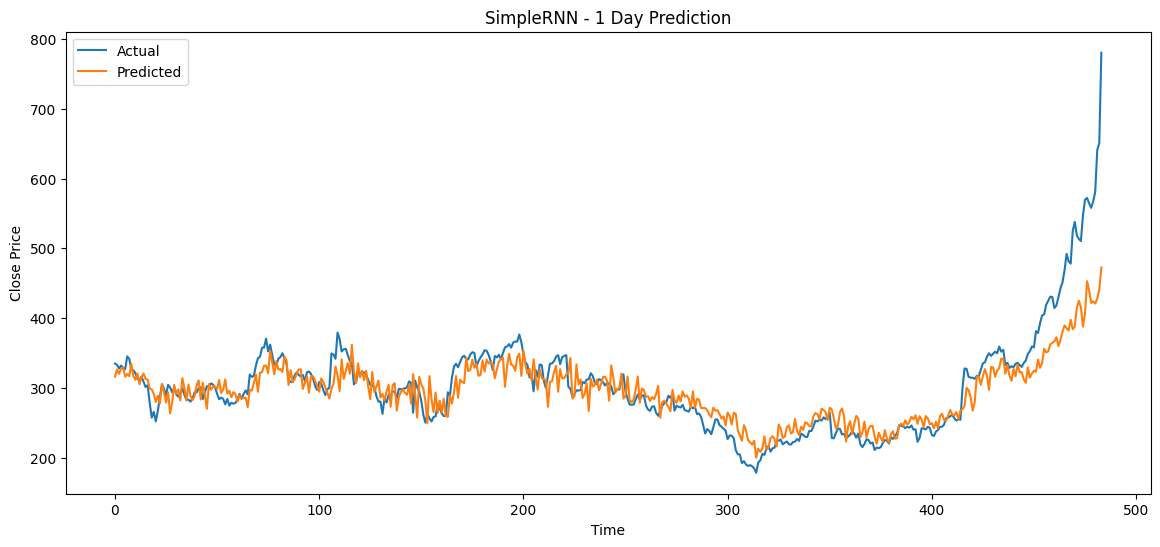

In [107]:
# Plot
plt.figure(figsize=(14,6))
plt.plot(y_test_1_actual, label="Actual")
plt.plot(rnn_pred_1_actual, label="Predicted")
plt.title("SimpleRNN - 1 Day Prediction")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# 14. Train LSTM for 1-day

In [108]:
lstm_model_1 = build_lstm_model((X_train_1.shape[1], 1))

history_lstm_1 = lstm_model_1.fit(
    X_train_1, y_train_1,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.0218 - val_loss: 0.0029
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0025 - val_loss: 0.0036
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0021 - val_loss: 0.0032
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0021 - val_loss: 0.0036
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0021 - val_loss: 0.0046
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0020 - val_loss: 0.0023
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0021 - val_loss: 0.0063
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0019 - val_loss: 0.0032
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0

In [109]:
# Evaluate
lstm_pred_1 = lstm_model_1.predict(X_test_1, verbose=0)
lstm_pred_1_actual = scaler.inverse_transform(lstm_pred_1)

lstm_mse_1 = mean_squared_error(y_test_1_actual, lstm_pred_1_actual)
lstm_rmse_1 = np.sqrt(lstm_mse_1)
lstm_mae_1 = mean_absolute_error(y_test_1_actual, lstm_pred_1_actual)

print("LSTM 1-Day")
print("MSE :", lstm_mse_1)
print("RMSE:", lstm_rmse_1)
print("MAE :", lstm_mae_1)

LSTM 1-Day
MSE : 844.9133515854003
RMSE: 29.06739327124812
MAE : 20.906452260933868


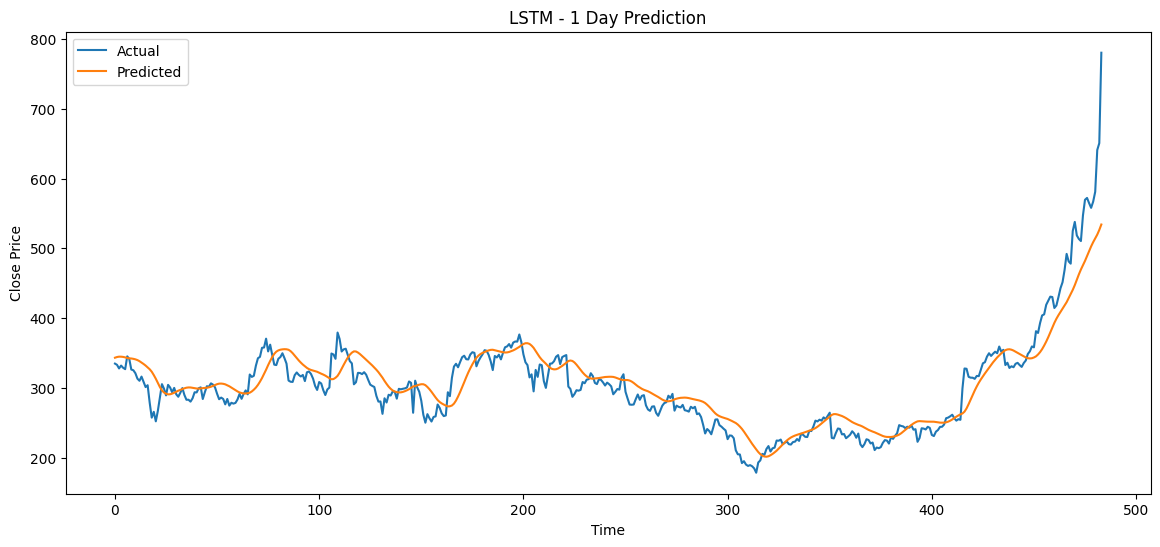

In [110]:
# Plot
plt.figure(figsize=(14,6))
plt.plot(y_test_1_actual, label="Actual")
plt.plot(lstm_pred_1_actual, label="Predicted")
plt.title("LSTM - 1 Day Prediction")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# 15. Proper GridSearchCV tuning for LSTM

## Hyperparameter Tuning
GridSearchCV was used with TimeSeriesSplit to tune the LSTM model. TimeSeriesSplit was chosen instead of random cross-validation to avoid data leakage in sequential stock data.

In [111]:
# Flattened version for scikeras-compatible wrapper
X_train_grid = X_train_1.reshape((X_train_1.shape[0], X_train_1.shape[1], 1))

def create_lstm_for_grid(units=50, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units=units, input_shape=(X_train_grid.shape[1], 1)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

lstm_reg = KerasRegressor(
    model=create_lstm_for_grid,
    verbose=0,
    epochs=10,
    batch_size=32
)

param_grid = {
    "model__units": [32, 50],
    "model__dropout_rate": [0.1, 0.2],
    "model__learning_rate": [0.001, 0.0005]
}

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    estimator=lstm_reg,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=1
)

grid_result = grid.fit(X_train_grid, y_train_1)
print("Best Parameters:", grid_result.best_params_)
print("Best Score:", grid_result.best_score_)

Best Parameters: {'model__dropout_rate': 0.1, 'model__learning_rate': 0.001, 'model__units': 50}
Best Score: -0.0018068485098687928


# 16. Reusable function for any horizon

In [112]:
def train_and_evaluate_models(train_scaled, test_scaled, horizon=1, lookback=60):
    X_train, y_train = create_sequences(train_scaled, lookback=lookback, horizon=horizon)
    combined = np.concatenate((train_scaled[-lookback:], test_scaled), axis=0)
    X_test, y_test = create_sequences(combined, lookback=lookback, horizon=horizon)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # SimpleRNN
    rnn_model = build_simplernn_model((X_train.shape[1], 1))
    rnn_model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=15,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    rnn_pred = rnn_model.predict(X_test, verbose=0)

    # LSTM
    lstm_model = build_lstm_model((X_train.shape[1], 1))
    lstm_model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=15,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    lstm_pred = lstm_model.predict(X_test, verbose=0)

    y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
    rnn_pred_actual = scaler.inverse_transform(rnn_pred)
    lstm_pred_actual = scaler.inverse_transform(lstm_pred)

    results = {
        "y_test_actual": y_test_actual,
        "rnn_pred_actual": rnn_pred_actual,
        "lstm_pred_actual": lstm_pred_actual,
        "rnn_mse": mean_squared_error(y_test_actual, rnn_pred_actual),
        "rnn_rmse": np.sqrt(mean_squared_error(y_test_actual, rnn_pred_actual)),
        "rnn_mae": mean_absolute_error(y_test_actual, rnn_pred_actual),
        "lstm_mse": mean_squared_error(y_test_actual, lstm_pred_actual),
        "lstm_rmse": np.sqrt(mean_squared_error(y_test_actual, lstm_pred_actual)),
        "lstm_mae": mean_absolute_error(y_test_actual, lstm_pred_actual)
    }

    return results

# 17. 5-day prediction

In [113]:
results_5 = train_and_evaluate_models(train_scaled, test_scaled, horizon=5, lookback=60)

print("SimpleRNN 5-Day RMSE:", results_5["rnn_rmse"])
print("LSTM 5-Day RMSE:", results_5["lstm_rmse"])

SimpleRNN 5-Day RMSE: 42.139850988814594
LSTM 5-Day RMSE: 38.359195618830114


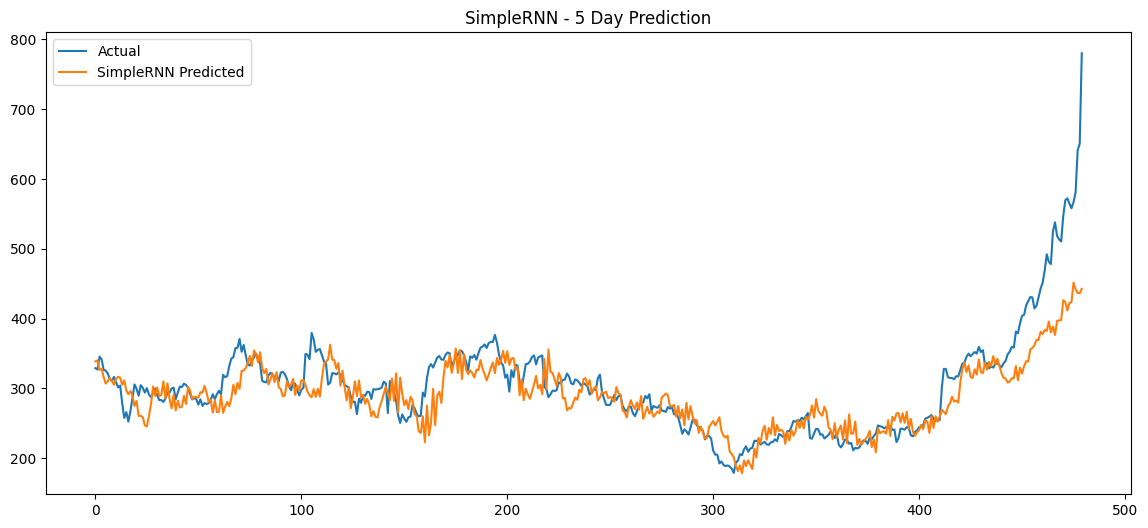

In [114]:
plt.figure(figsize=(14,6))
plt.plot(results_5["y_test_actual"], label="Actual")
plt.plot(results_5["rnn_pred_actual"], label="SimpleRNN Predicted")
plt.title("SimpleRNN - 5 Day Prediction")
plt.legend()
plt.show()

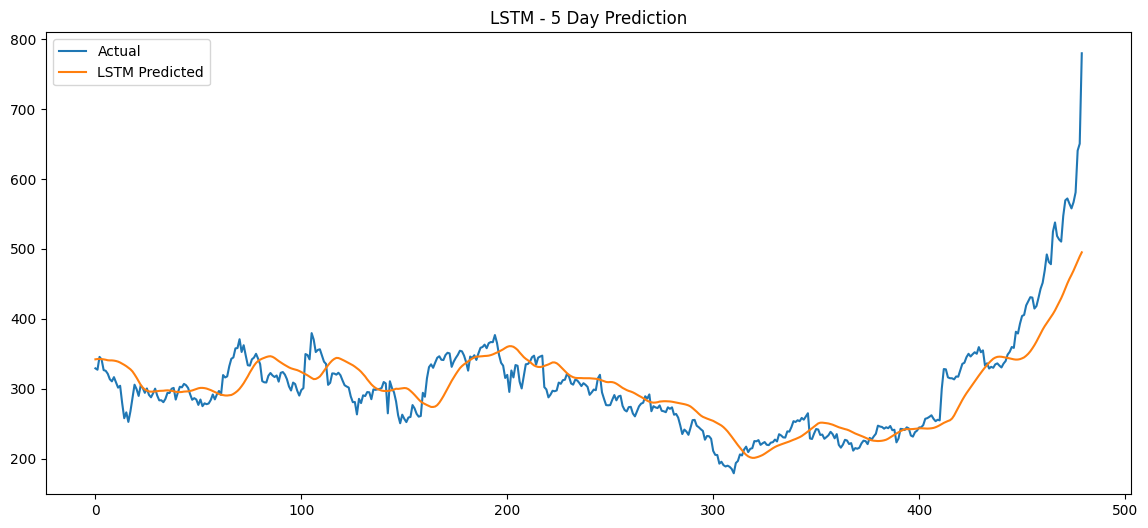

In [115]:
plt.figure(figsize=(14,6))
plt.plot(results_5["y_test_actual"], label="Actual")
plt.plot(results_5["lstm_pred_actual"], label="LSTM Predicted")
plt.title("LSTM - 5 Day Prediction")
plt.legend()
plt.show()

# 18. 10-day prediction

In [116]:
results_10 = train_and_evaluate_models(train_scaled, test_scaled, horizon=10, lookback=60)

print("SimpleRNN 10-Day RMSE:", results_10["rnn_rmse"])
print("LSTM 10-Day RMSE:", results_10["lstm_rmse"])

SimpleRNN 10-Day RMSE: 57.353934172814846
LSTM 10-Day RMSE: 47.181860103776614


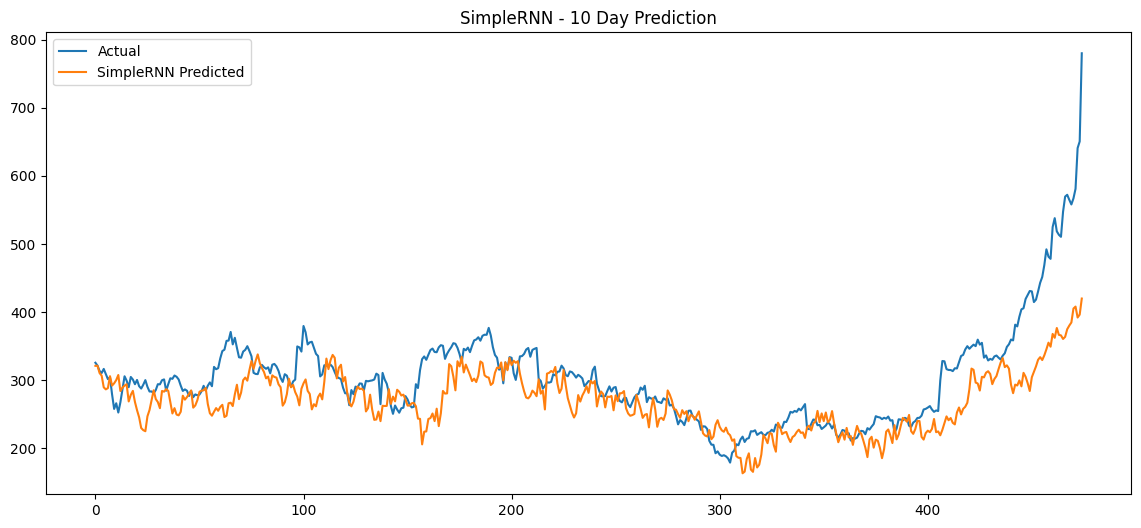

In [117]:
plt.figure(figsize=(14,6))
plt.plot(results_10["y_test_actual"], label="Actual")
plt.plot(results_10["rnn_pred_actual"], label="SimpleRNN Predicted")
plt.title("SimpleRNN - 10 Day Prediction")
plt.legend()
plt.show()

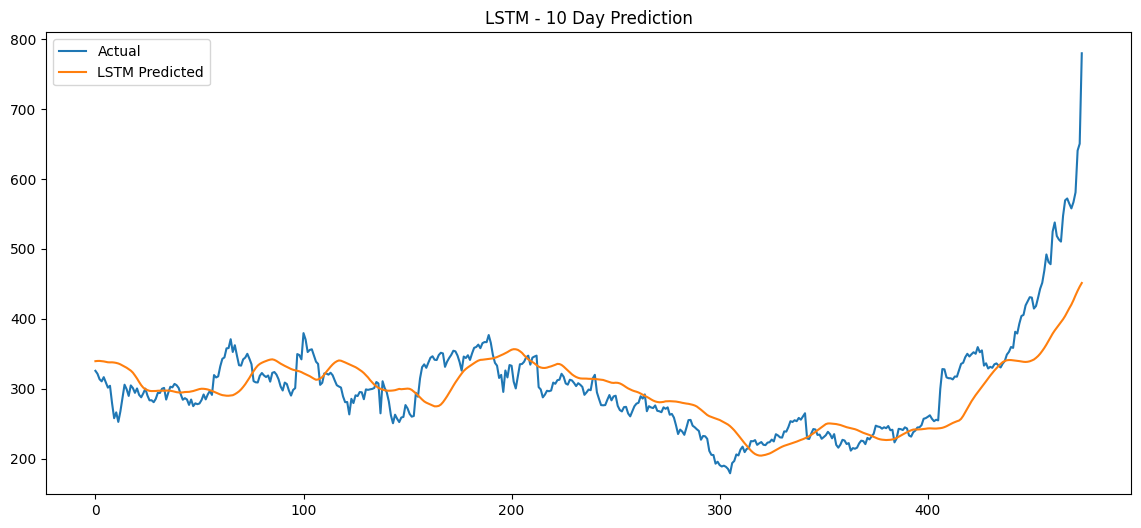

In [118]:
plt.figure(figsize=(14,6))
plt.plot(results_10["y_test_actual"], label="Actual")
plt.plot(results_10["lstm_pred_actual"], label="LSTM Predicted")
plt.title("LSTM - 10 Day Prediction")
plt.legend()
plt.show()

# 19. Final comparison table

In [119]:
comparison_df = pd.DataFrame({
    "Horizon": ["1-Day", "1-Day", "5-Day", "5-Day", "10-Day", "10-Day"],
    "Model": ["SimpleRNN", "LSTM", "SimpleRNN", "LSTM", "SimpleRNN", "LSTM"],
    "MSE": [rnn_mse_1, lstm_mse_1, results_5["rnn_mse"], results_5["lstm_mse"], results_10["rnn_mse"], results_10["lstm_mse"]],
    "RMSE": [rnn_rmse_1, lstm_rmse_1, results_5["rnn_rmse"], results_5["lstm_rmse"], results_10["rnn_rmse"], results_10["lstm_rmse"]],
    "MAE": [rnn_mae_1, lstm_mae_1, results_5["rnn_mae"], results_5["lstm_mae"], results_10["rnn_mae"], results_10["lstm_mae"]]
})

comparison_df

,Horizon,Model,MSE,RMSE,MAE
0,1-Day,SimpleRNN,1425.834437,37.760223,22.948307
1,1-Day,LSTM,844.913352,29.067393,20.906452
2,5-Day,SimpleRNN,1775.767041,42.139851,27.082170
3,5-Day,LSTM,1471.427889,38.359196,27.381846
4,10-Day,SimpleRNN,3289.473765,57.353934,38.709333
5,10-Day,LSTM,2226.127923,47.181860,33.195203


# 20. Best model

In [120]:
best_model_row = comparison_df.loc[comparison_df["RMSE"].idxmin()]
print("Best Model Summary")
print(best_model_row)

Best Model Summary
Horizon         1-Day
Model            LSTM
MSE        844.913352
RMSE        29.067393
MAE         20.906452
Name: 1, dtype: object


# 21. Save models

In [121]:
rnn_model_1.save("simplernn_1day.keras")
lstm_model_1.save("lstm_1day.keras")
print("Models saved successfully")

Models saved successfully


# 

# 22. Final conclusion markdown cell

# ## Conclusion

In this project, Tesla stock closing prices were predicted using two deep learning models: SimpleRNN and LSTM. Historical stock price data was cleaned, visualized, scaled, and transformed into time-series sequences using a 60-day lookback window. The models were trained to predict future closing prices for 1-day, 5-day, and 10-day horizons.

The results show that both models can capture stock price trends, but LSTM generally performs better because it is more effective at learning long-term dependencies in sequential data. Prediction accuracy is highest for 1-day forecasting and decreases as the prediction horizon increases to 5 and 10 days.

This project demonstrates the usefulness of recurrent deep learning models for financial time-series prediction. However, stock prices are influenced by external factors such as news, market sentiment, and macroeconomic events, so future improvements could include additional features such as sentiment analysis, competitor stock data, and economic indicators.